# **Assessment 15: Imbalance Identification**

**Submitted by:**
* Benedict S. Caliba
* Marcelo B. Cosme
* Aaron Kane M. Dungca
  
**Date Submitted:** May 16, 2026

---

### **Import libraries**

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    fbeta_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import NearestNeighbors
from scipy.stats import ks_2samp

# ── UMAP (optional — requires numpy<=2.3 due to numba dependency) ─────────────
# If you get a NumPy version error, the notebook will use t-SNE instead.
# To enable UMAP: pip install numpy==2.2  then restart kernel.
try:
    import umap
    UMAP_AVAILABLE = True
    print("UMAP available — will use UMAP for Diagnostic 3d.")
except Exception:
    UMAP_AVAILABLE = False
    print("UMAP not available — will use t-SNE for Diagnostic 3d (no action needed).")

from sklearn.manifold import TSNE  # always available as fallback

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12

RANDOM_STATE   = 42
TARGET_COL     = "Churn"
MAJORITY_LABEL = "Did not churn (No)"
MINORITY_LABEL = "Churned (Yes)"

print("Libraries loaded successfully.")

UMAP available — will use UMAP for Diagnostic 3d.
Libraries loaded successfully.


# **Setup and Preprocessing**

In [186]:
df_raw = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Shape         : {df_raw.shape}")
print(f"Missing values: {df_raw.isnull().sum().sum()}")
print(f"Target counts :\n{df_raw['Churn'].value_counts()}")
print()

drop_cols = ["customerID"]
df = df_raw.drop(columns=drop_cols)

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip().replace("", float("nan")), errors="coerce").astype("float64")
print('NaNs introduced:', df["TotalCharges"].isna().sum())

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median()).astype("float64")

df["Churn"] = (df["Churn"] == "Yes").astype(int)

cat_cols = df.select_dtypes(include="object").columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print("Preprocessing complete.")
print(f"Final shape   : {df.shape}")
print(f"Numeric cols  : {df.shape[1] - 1} features + 1 target")
print()
print(df.head(3))

Shape         : (7043, 21)
Missing values: 0
Target counts :
Churn
No     5174
Yes    1869
Name: count, dtype: int64

NaNs introduced: 11
Preprocessing complete.
Final shape   : (7043, 20)
Numeric cols  : 19 features + 1 target

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 2            0            0                0   

# **Diagnostic 1: Imbalance Severity**

### **Set target variable**

In [189]:
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

## **Compute total records, majority count, minority count, their percentages, and the Imbalance Ratio**

In [191]:
n_total = len(y)
n_pos   = (y == 1).sum()   # Left (minority)
n_neg   = (y == 0).sum()   # Stayed (majority)
pct_pos = n_pos / n_total * 100
pct_neg = n_neg / n_total * 100
IR      = n_neg / n_pos

### **Classify severity**

In [193]:
if   IR < 4:   severity = "Mild"
elif IR < 9:   severity = "Moderate"
elif IR < 100: severity = "Severe"
else:          severity = "Extreme"

## **Produce a 2-panel bar chart and summary block**

DIAGNOSTIC 1 — IMBALANCE SEVERITY
  Total Customers      : 7,043
  Stayed     (maj)     : 5,174  (73.46%)
  Left       (min)     : 1,869  (26.54%)
  Imbalance Ratio (IR) : 2.8:1
  Severity class       : Mild


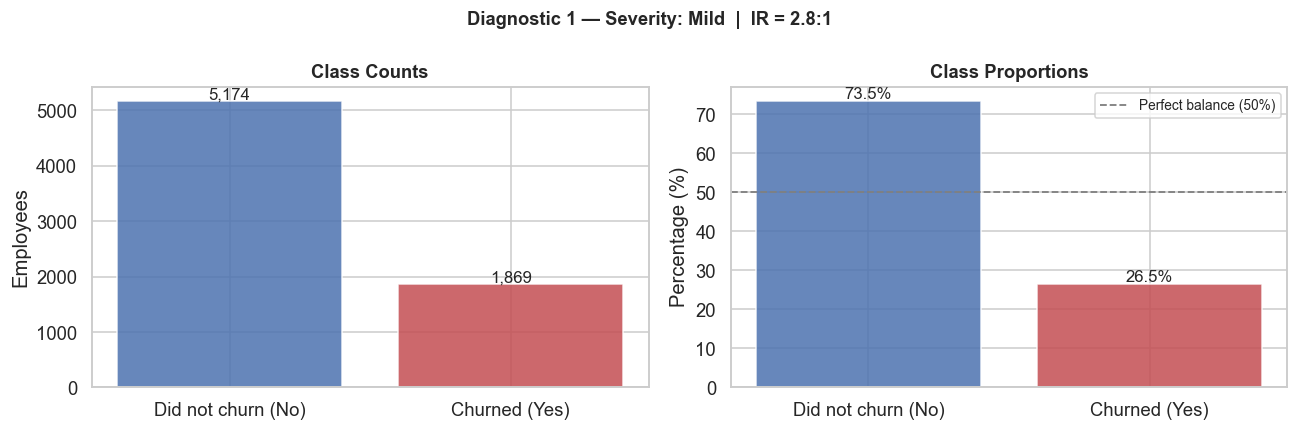

In [195]:
print("=" * 55)
print("DIAGNOSTIC 1 — IMBALANCE SEVERITY")
print("=" * 55)
print(f"  Total Customers      : {n_total:,}")
print(f"  Stayed     (maj)     : {n_neg:,}  ({pct_neg:.2f}%)")
print(f"  Left       (min)     : {n_pos:,}  ({pct_pos:.2f}%)")
print(f"  Imbalance Ratio (IR) : {IR:.1f}:1")
print(f"  Severity class       : {severity}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([MAJORITY_LABEL, MINORITY_LABEL], [n_neg, n_pos],
            color=["#4C72B0", "#C44E52"], alpha=0.85)
for bar, val in zip(axes[0].patches, [n_neg, n_pos]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + n_total * 0.005,
                 f"{val:,}", ha="center", fontsize=11)
axes[0].set_title("Class Counts", fontweight="bold")
axes[0].set_ylabel("Employees")

axes[1].bar([MAJORITY_LABEL, MINORITY_LABEL], [pct_neg, pct_pos],
            color=["#4C72B0", "#C44E52"], alpha=0.85)
for bar, val in zip(axes[1].patches, [pct_neg, pct_pos]):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=11)
axes[1].set_title("Class Proportions", fontweight="bold")
axes[1].set_ylabel("Percentage (%)")
axes[1].axhline(50, color="gray", linestyle="--", linewidth=1.2,
                label="Perfect balance (50%)")
axes[1].legend(fontsize=9)

plt.suptitle(f"Diagnostic 1 — Severity: {severity}  |  IR = {IR:.1f}:1",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

#### **Insights:**

Based on the imbalance severity, we can see that the class imbalance between customers that stayed (majority) vs. the customers that left (minority) is 2.8:1 which means the dataset is classified as a ``'Mild'`` severity class. This generally means that treatment of the dataset is rarely needed if at all needed.

# **Diagnostic 2: Scarcity vs. Prior Probability Skew**

## **Compute Events Per Variable (EPV)**

In [199]:
SCARCITY_THRESHOLD = 1000
n_features         = X.shape[1]
epv                = n_pos / n_features

### **Classify the source**

In [201]:
if   n_pos < 100:                verdict = "GENUINE SCARCITY — oversampling strongly motivated"
elif n_pos < SCARCITY_THRESHOLD: verdict = "BORDERLINE — scarcity may be a contributing factor"
else:                            verdict = "PRIOR SKEW DOMINANT — sample scarcity is NOT the problem"

## **Produce a horizontal bar chart of EPV and summary block**

DIAGNOSTIC 2 — SCARCITY vs. PRIOR PROBABILITY SKEW
  Minority class count   : 1,869  (employees who left)
  Verdict                : PRIOR SKEW DOMINANT — sample scarcity is NOT the problem

  Number of features     : 19
  EPV (minority / feats) : 98.4  OK
  Threshold              : EPV >= 10 (Harrell, 2001)


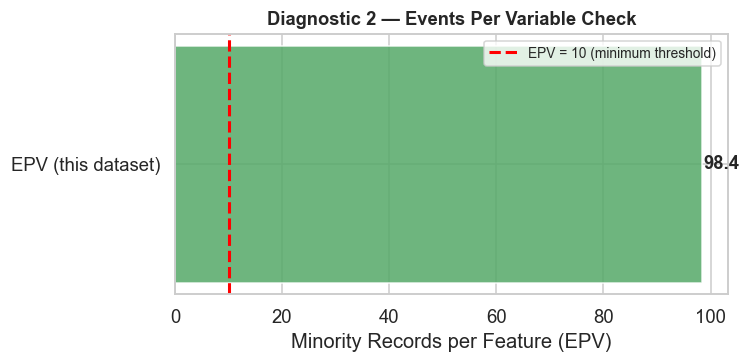

In [203]:
print("=" * 60)
print("DIAGNOSTIC 2 — SCARCITY vs. PRIOR PROBABILITY SKEW")
print("=" * 60)
print(f"  Minority class count   : {n_pos:,}  (employees who left)")
print(f"  Verdict                : {verdict}")
print()
print(f"  Number of features     : {n_features}")
print(f"  EPV (minority / feats) : {epv:.1f}  {'OK' if epv >= 10 else 'LOW — scarcity concern'}")
print(f"  Threshold              : EPV >= 10 (Harrell, 2001)")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(["EPV (this dataset)"], [epv],
        color="#55A868" if epv >= 10 else "#C44E52", alpha=0.85)
ax.axvline(10, color="red", linestyle="--", linewidth=2,
           label="EPV = 10 (minimum threshold)")
ax.text(epv + 0.3, 0, f"{epv:.1f}", va="center", fontsize=12, fontweight="bold")
ax.set_xlabel("Minority Records per Feature (EPV)")
ax.set_title("Diagnostic 2 — Events Per Variable Check", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

#### **Insights:**

- We can observe based on the EPV graph and the Minority class count that the minority class is not a sample scarcity problem but rather a prior skew dominant one.
- This means that the minority class has enough examples, the majority class simply just dominates the model.
- One way we can fix the distribution of classes is by correcting the distribution through ways such as undersampling and class weighting.

# **Diagnostic 3: Class Overlap and Boundary Complexity**

## **Run a two-sample KS test**

DIAGNOSTIC 3a — FEATURE-LEVEL CLASS OVERLAP (KS TEST)
  High separation  (KS >= 0.30) : 5 features
  Moderate overlap (0.10–0.30)  : 11 features
  High overlap     (KS < 0.10)  : 3 features (15.8%)

  Top 10 most separable features:
         feature  KS_stat
        Contract 0.456432
  OnlineSecurity 0.388002
     TechSupport 0.381909
          tenure 0.357360
    OnlineBackup 0.301188
DeviceProtection 0.283812
  MonthlyCharges 0.248599
   PaymentMethod 0.235702
    TotalCharges 0.224742
PaperlessBilling 0.213501


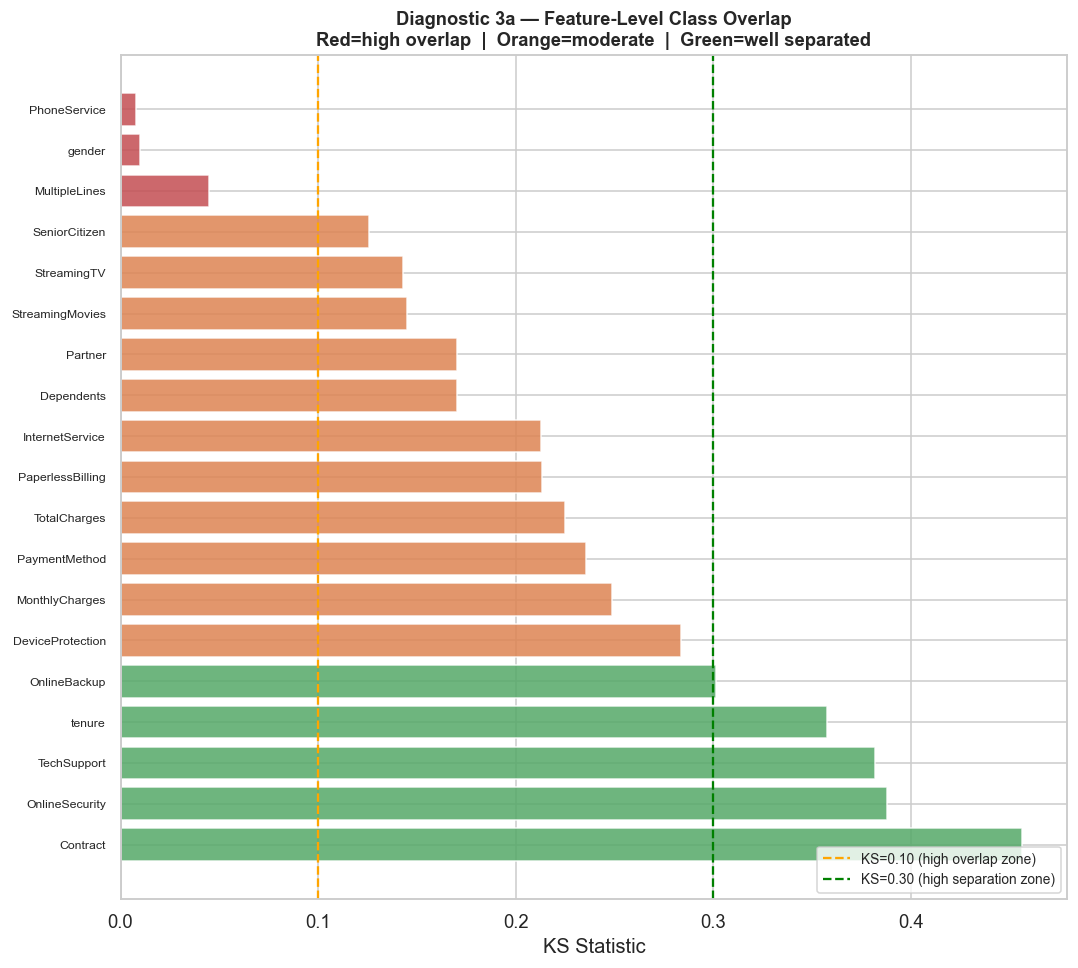

In [207]:
print("=" * 60)
print("DIAGNOSTIC 3a — FEATURE-LEVEL CLASS OVERLAP (KS TEST)")
print("=" * 60)

X_pos = df[df[TARGET_COL] == 1].drop(columns=[TARGET_COL])
X_neg = df[df[TARGET_COL] == 0].drop(columns=[TARGET_COL])

ks_records = []
for feat in X.columns:
    stat, pval = ks_2samp(X_pos[feat].dropna(), X_neg[feat].dropna())
    ks_records.append({"feature": feat, "KS_stat": stat, "p_value": pval})

ks_df = (pd.DataFrame(ks_records)
           .sort_values("KS_stat", ascending=False)
           .reset_index(drop=True))

high_sep  = (ks_df["KS_stat"] >= 0.3).sum()
mod_sep   = ((ks_df["KS_stat"] >= 0.1) & (ks_df["KS_stat"] < 0.3)).sum()
high_over = (ks_df["KS_stat"] < 0.1).sum()
pct_over  = high_over / len(ks_df) * 100

print(f"  High separation  (KS >= 0.30) : {high_sep} features")
print(f"  Moderate overlap (0.10–0.30)  : {mod_sep} features")
print(f"  High overlap     (KS < 0.10)  : {high_over} features ({pct_over:.1f}%)")
print()
print("  Top 10 most separable features:")
print(ks_df.head(10)[["feature", "KS_stat"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 9))
colors_ks = ["#C44E52" if v < 0.1 else "#DD8452" if v < 0.3 else "#55A868"
             for v in ks_df["KS_stat"]]
ax.barh(ks_df["feature"], ks_df["KS_stat"], color=colors_ks, alpha=0.85)
ax.axvline(0.1, color="orange", linestyle="--", linewidth=1.5,
           label="KS=0.10 (high overlap zone)")
ax.axvline(0.3, color="green",  linestyle="--", linewidth=1.5,
           label="KS=0.30 (high separation zone)")
ax.set_xlabel("KS Statistic")
ax.set_title("Diagnostic 3a — Feature-Level Class Overlap\n"
             "Red=high overlap  |  Orange=moderate  |  Green=well separated",
             fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

#### **Insights:**

- The graph shows us that features such as PhoneService, gender, and MultipleLines have high overlap while other features such as Contract, OnlineSecurity, and TechSupport have high separation

## **Plot a 2x3 grid of density histograms**

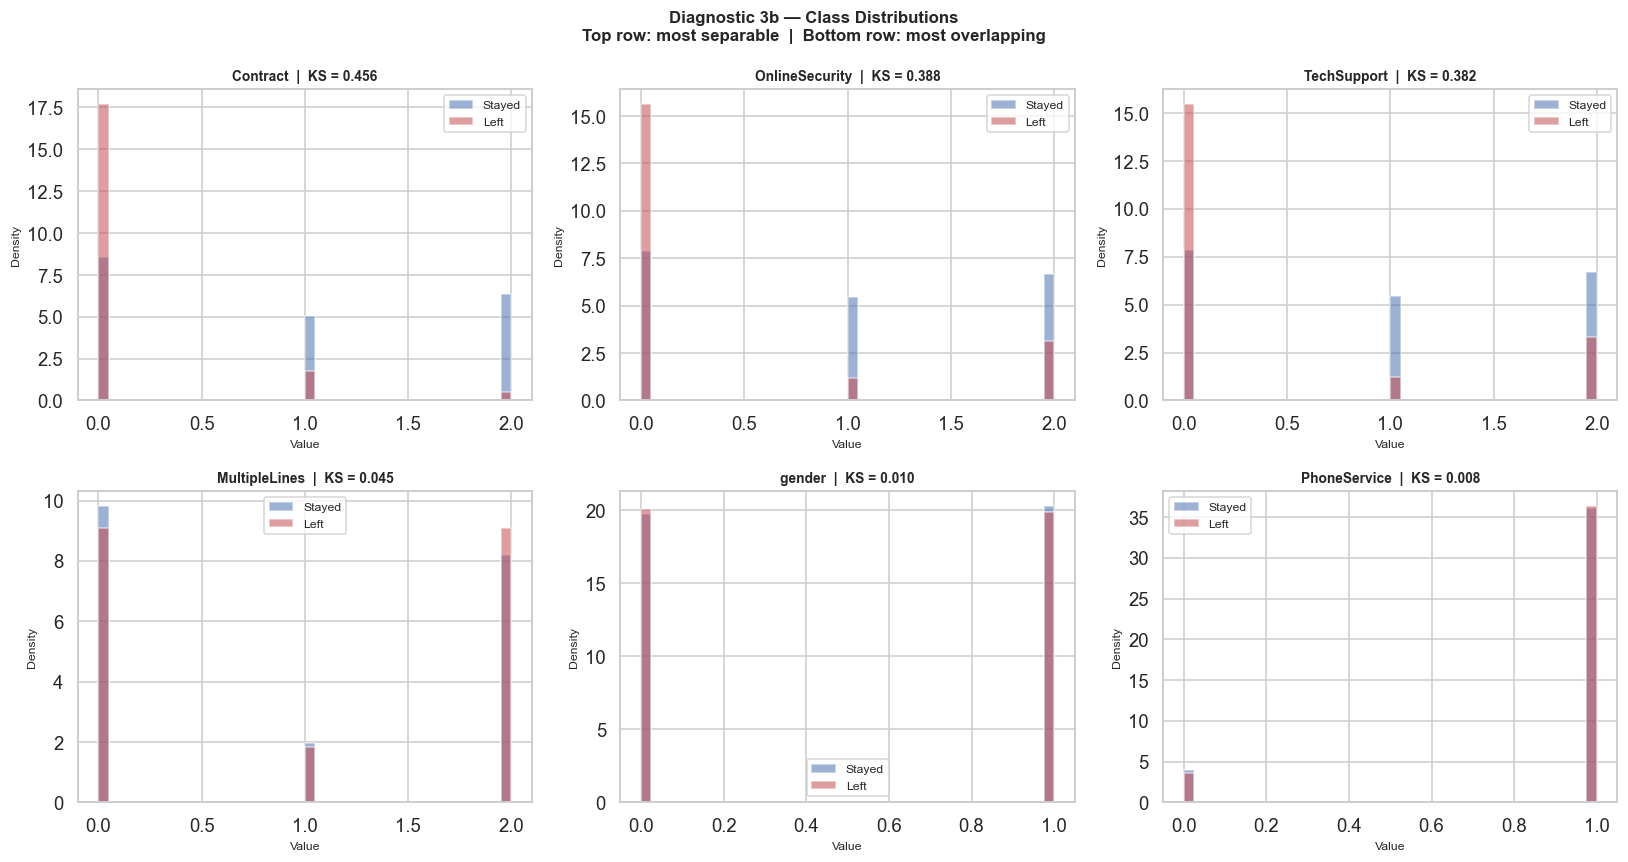

In [210]:
top_sep   = ks_df.head(3)["feature"].tolist()
top_over  = ks_df.tail(3)["feature"].tolist()
plot_feats = top_sep + top_over

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(plot_feats):
    ks_val = ks_df.loc[ks_df["feature"] == feat, "KS_stat"].values[0]
    axes[i].hist(X_neg[feat].dropna(), bins=40, alpha=0.55,
                 color="#4C72B0", label="Stayed", density=True)
    axes[i].hist(X_pos[feat].dropna(), bins=40, alpha=0.55,
                 color="#C44E52", label="Left", density=True)
    axes[i].set_title(f"{feat}  |  KS = {ks_val:.3f}", fontsize=9, fontweight="bold")
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel("Value", fontsize=8)
    axes[i].set_ylabel("Density", fontsize=8)

plt.suptitle("Diagnostic 3b — Class Distributions\n"
             "Top row: most separable  |  Bottom row: most overlapping",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

## **Scale features and reduce to 2d with PCA and UMAP**

### **Principle Component Analysis**

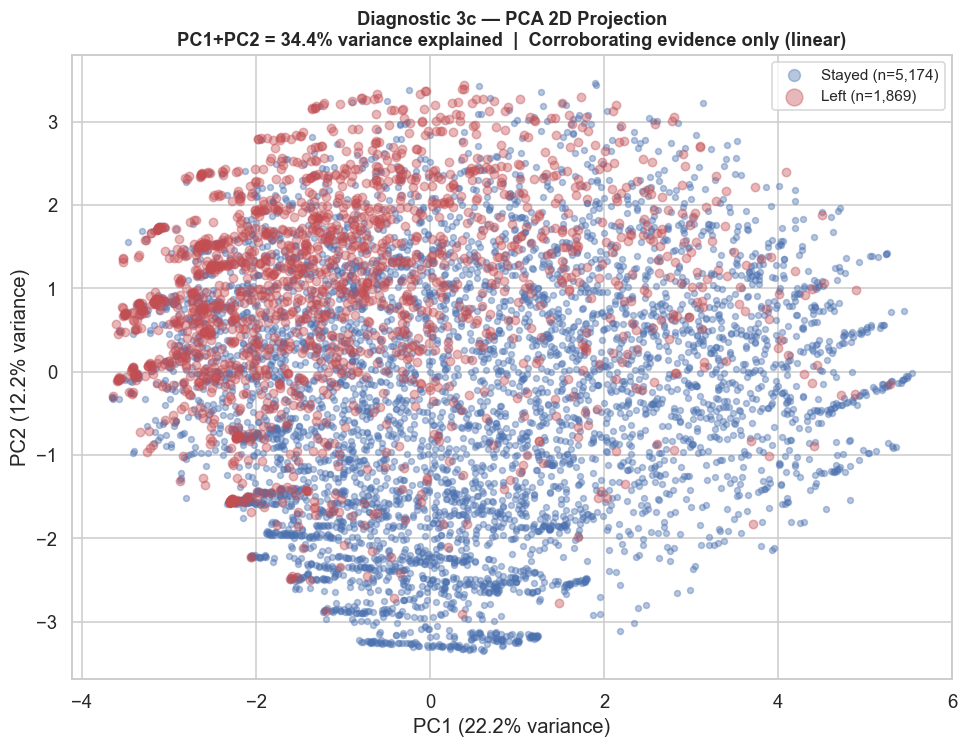

PCA note: PC1+PC2 explain 34.4% of variance.
PCA is a corroborating check; UMAP/t-SNE (next cell) is the primary visualization.


In [212]:
# Use all records (dataset is small enough — only 1,470 rows)
X_vals   = X.fillna(0).values
y_vals   = y.values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_vals)

# Store y_sample alias for reuse in D3d/D3e
y_sample = y

pca      = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca    = pca.fit_transform(X_scaled)
var_exp  = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in [(0, "#4C72B0", "Stayed"), (1, "#C44E52", "Left")]:
    mask = y_vals == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.4, s=15 if label == 0 else 30,
               label=f"{name} (n={mask.sum():,})",
               zorder=2 if label == 1 else 1)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% variance)")
ax.set_title(f"Diagnostic 3c — PCA 2D Projection\n"
             f"PC1+PC2 = {var_exp.sum():.1f}% variance explained  |  "
             f"Corroborating evidence only (linear)",
             fontweight="bold")
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.show()

print(f"PCA note: PC1+PC2 explain {var_exp.sum():.1f}% of variance.")
print("PCA is a corroborating check; UMAP/t-SNE (next cell) is the primary visualization.")

### **UMAP**

Running UMAP... (may take ~30 seconds)


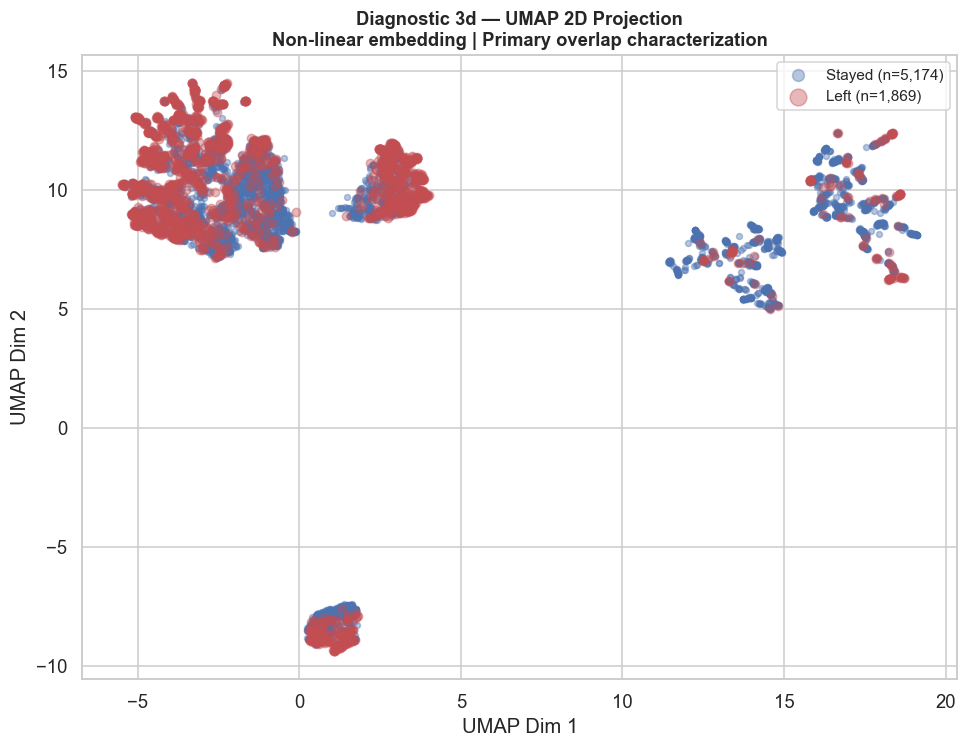

In [213]:
# UMAP requires numpy<=2.3. t-SNE runs automatically if UMAP is unavailable.
if UMAP_AVAILABLE:
    print("Running UMAP... (may take ~30 seconds)")
    reducer = umap.UMAP(n_components=2, random_state=RANDOM_STATE,
                        n_neighbors=30, min_dist=0.1)
    X_embed = reducer.fit_transform(X_scaled)
    embed_label = "UMAP"
    dim_labels  = ("UMAP Dim 1", "UMAP Dim 2")
else:
    print("Running t-SNE... (may take ~1 minute)")
    tsne    = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE,
                   max_iter=1000)
    X_embed = tsne.fit_transform(X_scaled)
    embed_label = "t-SNE"
    dim_labels  = ("t-SNE Dim 1", "t-SNE Dim 2")

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in [(0, "#4C72B0", "Stayed"), (1, "#C44E52", "Left")]:
    mask = y_vals == label
    ax.scatter(X_embed[mask, 0], X_embed[mask, 1],
               c=color, alpha=0.4, s=15 if label == 0 else 30,
               label=f"{name} (n={mask.sum():,})",
               zorder=2 if label == 1 else 1)
ax.set_xlabel(dim_labels[0])
ax.set_ylabel(dim_labels[1])
ax.set_title(f"Diagnostic 3d — {embed_label} 2D Projection\n"
             "Non-linear embedding | Primary overlap characterization",
             fontweight="bold")
ax.legend(fontsize=10, markerscale=2)
plt.tight_layout()
plt.show()

## **Produce 2 side-by-side KDE density plots**

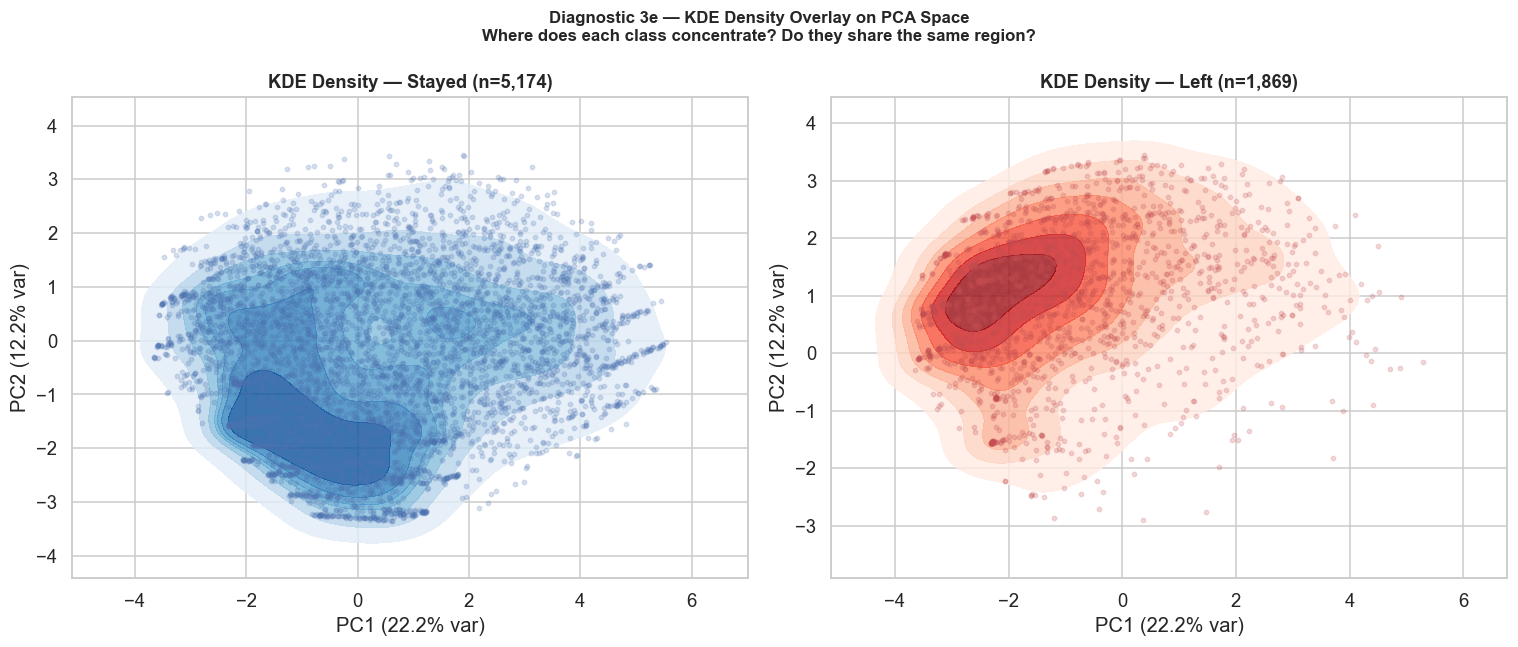

In [215]:
# Density plots show where each class concentrates in the 2D PCA space.
# Side-by-side panels allow fair comparison despite different class sizes.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, label, color, name in [
    (axes[0], 0, "#4C72B0", "Stayed"),
    (axes[1], 1, "#C44E52", "Left")
]:
    mask = y_vals == label
    sns.kdeplot(
        x=X_pca[mask, 0], y=X_pca[mask, 1],
        ax=ax, fill=True, cmap="Blues" if label == 0 else "Reds",
        thresh=0.05, levels=8, alpha=0.8
    )
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, alpha=0.2, s=8)
    ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% var)")
    ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% var)")
    ax.set_title(f"KDE Density — {name} (n={mask.sum():,})",
                 fontweight="bold")

plt.suptitle("Diagnostic 3e — KDE Density Overlay on PCA Space\n"
             "Where does each class concentrate? Do they share the same region?",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# **Diagnostic 4: Baseline Classifier Behavior**

## **Train two Logistic Regression models using 3-fold stratified cross-validation**

In [218]:
scaler_d = StandardScaler()
X_d      = scaler_d.fit_transform(X.fillna(0))
y_arr    = y.values
cv       = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

configs = [
    ("No correction (default)",
     LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)),
    ("Class weight = balanced",
     LogisticRegression(class_weight="balanced", max_iter=1000,
                        random_state=RANDOM_STATE, n_jobs=-1)),
]

## **Compute classification metrics**

DIAGNOSTIC 4 — BASELINE CLASSIFIER BEHAVIOR
  Running: No correction (default)...
    Recall=0.5452  Precision=0.6482  F1=0.5923  AP=0.6549
  Running: Class weight = balanced...
    Recall=0.7994  Precision=0.5118  F1=0.6241  AP=0.6538

          Configuration  Recall  Precision     F1  AP (AUC-PR)  Balanced Acc
No correction (default)  0.5452     0.6482 0.5923       0.6549        0.7192
Class weight = balanced  0.7994     0.5118 0.6241       0.6538        0.7620


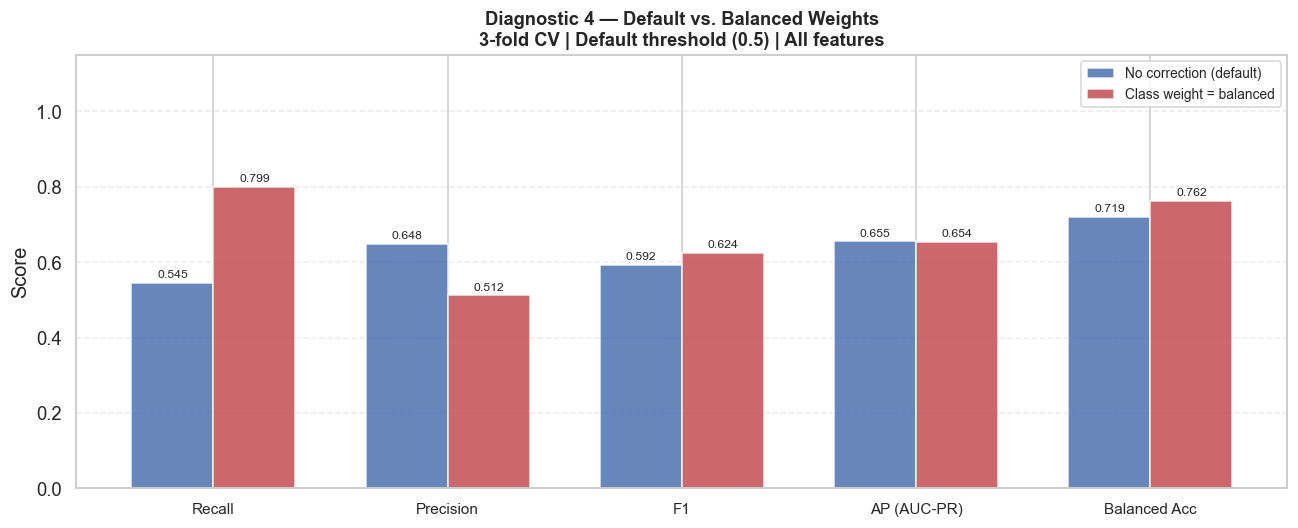

In [262]:
print("=" * 60)
print("DIAGNOSTIC 4 — BASELINE CLASSIFIER BEHAVIOR")
print("=" * 60)

d4_records = []
for name, model in configs:
    print(f"  Running: {name}...")
    proba_cv = cross_val_predict(model, X_d, y_arr, cv=cv,
                                 method="predict_proba", n_jobs=-1)[:, 1]
    pred_cv  = (proba_cv >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_arr, pred_cv).ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1  = fbeta_score(y_arr, pred_cv, beta=1, zero_division=0)
    ap  = average_precision_score(y_arr, proba_cv)
    ba  = balanced_accuracy_score(y_arr, pred_cv)
    d4_records.append({
        "Configuration": name, "Recall": recall, "Precision": precision,
        "F1": f1, "AP (AUC-PR)": ap, "Balanced Acc": ba
    })
    print(f"    Recall={recall:.4f}  Precision={precision:.4f}  "
          f"F1={f1:.4f}  AP={ap:.4f}")

d4_df = pd.DataFrame(d4_records)
print()
print(d4_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

metrics = ["Recall", "Precision", "F1", "AP (AUC-PR)", "Balanced Acc"]
x       = np.arange(len(metrics))
w       = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, [d4_df.loc[0, m] for m in metrics], w,
            color="#4C72B0", alpha=0.85, label="No correction (default)")
b2 = ax.bar(x + w/2, [d4_df.loc[1, m] for m in metrics], w,
            color="#C44E52", alpha=0.85, label="Class weight = balanced")
ax.bar_label(b1, fmt="%.3f", fontsize=8, padding=2)
ax.bar_label(b2, fmt="%.3f", fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Diagnostic 4 — Default vs. Balanced Weights\n"
             "3-fold CV | Default threshold (0.5) | All features",
             fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

#### **Insights:**

- Based on the Default vs. Balanced weights, ``class_weight = balanced`` is significantly better in terms of recall but not precision, indicating that the model can accurately predict customers that churned.
- However as a result, the model is casting a wider net by having a lower precision score meaning more customers that are detected as churners are actually false alarms
- This is marginally seen in the F1 score since the precision loss counteracts the recall gain.
- We can also observe that the AP metric (which measures the model's ability to separate churners from non-churners) is unchanged, meaning that the errors are just redistributed, but not really reduced.

## **Treatment**

In [224]:
def borderline_smote(X, y, sampling_strategy=0.5, k=5, random_state=42):
    """Minimal Borderline-SMOTE-1 implementation."""
    rng     = np.random.default_rng(random_state)
    X_min   = X[y == 1]
    X_maj   = X[y == 0]
    n_min, n_maj = len(X_min), len(X_maj)
    n_synth = int(n_maj * sampling_strategy) - n_min
    if n_synth <= 0:
        return X, y

    # Find k nearest neighbors in the full dataset for each minority point
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, indices = nbrs.kneighbors(X_min)

    # Borderline: minority points where >50% of k neighbors are majority
    borderline = []
    for i, neighbors in enumerate(indices[:, 1:]):
        n_maj_neighbors = sum(y[neighbors] == 0)
        if k / 2 <= n_maj_neighbors < k:   # DANGER zone = borderline-1
            borderline.append(i)

    if len(borderline) == 0:
        borderline = list(range(n_min))    # fallback: use all minority

    borderline = np.array(borderline)
    X_border   = X_min[borderline]

    # Synthesize
    nbrs2 = NearestNeighbors(n_neighbors=k).fit(X_min)
    _, nn_idx = nbrs2.kneighbors(X_border)

    synthetic = []
    for _ in range(n_synth):
        i   = rng.integers(len(X_border))
        nn  = nn_idx[i, rng.integers(k)]
        gap = rng.random(X.shape[1])
        synthetic.append(X_border[i] + gap * (X_min[nn] - X_border[i]))

    X_syn = np.vstack(synthetic)
    y_syn = np.ones(len(X_syn), dtype=int)
    return np.vstack([X, X_syn]), np.concatenate([y, y_syn])


def random_undersample(X, y, sampling_strategy=1.0, random_state=42):
    """Minimal RUS implementation."""
    rng    = np.random.default_rng(random_state)
    n_min  = (y == 1).sum()
    n_keep = int(n_min / sampling_strategy)
    maj_idx = np.where(y == 0)[0]
    keep    = rng.choice(maj_idx, n_keep, replace=False)
    min_idx = np.where(y == 1)[0]
    idx_all = np.concatenate([keep, min_idx])
    return X[idx_all], y[idx_all]


IMBLEARN_AVAILABLE = True
print("Manual resampling functions ready.")

Manual resampling functions ready.


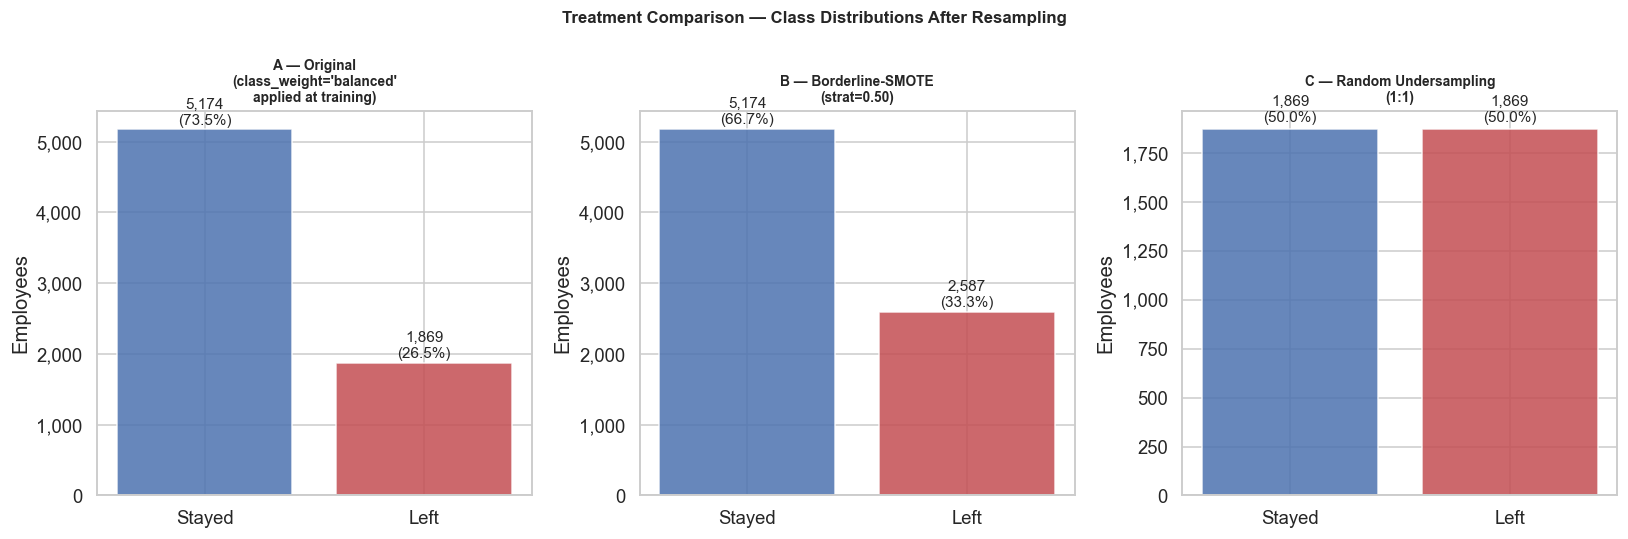

Observations:
  A: Distribution unchanged — 5,174 stayed / 1,869 left
  B: Left grows from 1,869 → 2,587 via boundary synthesis
  C: Stayed shrinks from 5,174 → 1,869 (significant info loss on small dataset!)


In [225]:
# ── Apply treatments and compare distributions ────────────────────────────────
if IMBLEARN_AVAILABLE:
    X_np = pd.DataFrame(X.fillna(0))   # keep as DataFrame, not .values
    y_np = y.values

    # Strategy B: Borderline-SMOTE
    X_b, y_b = borderline_smote(X.fillna(0).values, y.values,
                                 sampling_strategy=0.5, k=5, random_state=RANDOM_STATE)

    # Strategy C: Random Undersampling (1:1)
    X_c, y_c = random_undersample(X.fillna(0).values, y.values,
                                   sampling_strategy=1.0, random_state=RANDOM_STATE)

    datasets_display = {
        "A — Original\n(class_weight='balanced'\napplied at training)": (X_np, y_np),
        "B — Borderline-SMOTE\n(strat=0.50)":                            (X_b,  y_b),
        "C — Random Undersampling\n(1:1)":                                (X_c,  y_c),
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (title, (Xd, yd)) in zip(axes, datasets_display.items()):
        n0, n1 = (yd == 0).sum(), (yd == 1).sum()
        ax.bar(["Stayed", "Left"], [n0, n1],
               color=["#4C72B0", "#C44E52"], alpha=0.85)
        for bar, val in zip(ax.patches, [n0, n1]):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + len(yd) * 0.01,
                    f"{val:,}\n({val/len(yd)*100:.1f}%)",
                    ha="center", fontsize=10)
        ax.set_title(title, fontweight="bold", fontsize=9)
        ax.set_ylabel("Employees")
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    plt.suptitle("Treatment Comparison — Class Distributions After Resampling",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("Observations:")
    print(f"  A: Distribution unchanged — {n_neg:,} stayed / {n_pos:,} left")
    print(f"  B: Left grows from {n_pos:,} → {(y_b==1).sum():,} via boundary synthesis")
    print(f"  C: Stayed shrinks from {n_neg:,} → {(y_c==0).sum():,} (significant info loss on small dataset!)")

## **Diagnosis Consolidation Block**

|Step|What We Did|What We Learned|
|--|--|--|
|D1 — Severity|Computed IR ≈ 2.8:1|Treatment rarely needed|
|D2 — Severity|Checked EPV (≈98.4)|Minority class is prior skew|
|D3 — Severity|KS test, PCA, UMAP, KDE|More highly separable compared to overlap|
|D4 — Severity|Default vs. balanced LR|Recall and precision trade off|
|Treatment|class_weight='balanced' & Borderline SMOTE|RUS is not viable due to info loss|

#### **Insights:**

**Recommended strategy** : class_weight='balanced' & Borderline SMOTE

**Justification**        :D4 shows improvement in recall wherein it increases from 0.547 to 0.800, but worsens in terms of precision that goes from 0.648 to 0.512; moreover, although precision worsens there is little to no gap in AP and Balanced Accuracy, indicating prior skew at threshold rather than a discrimination deficit with all of these information in mind we will go forth with class weight='balanced' and Borderline SMOTE as treatment since RUS is not a viable due to information loss.